In [18]:
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

from scripts.model_registry import ModelRegistry
from scripts.shap import excecute_shap, extract_shap_importance

In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data loading

In [4]:
data_path = Path("data")

train_df = pd.read_csv(data_path / "titanic" / "train.csv")
test_df = pd.read_csv(data_path / "titanic" / "test.csv")

combined_df = pd.concat([train_df, test_df])

target = "Survived"

# Feature engineering

## Utils functions for data processing

In [5]:
def corrwt(col_names: List[str]) -> pd.DataFrame:
    return combined_df.groupby(col_names, observed=False)[target].agg(["mean", "count"])


def build_family_size_feature(df: pd.DataFrame) -> pd.Series:
    family_size = df["SibSp"] + df["Parch"] + 1
    return family_size


def build_family_size_cat_feature(df: pd.DataFrame) -> pd.Series:
    family_size = df["SibSp"] + df["Parch"] + 1
    bins = [-np.inf, 1, 2, 4, np.inf]
    labels = ["alone", "small", "medium", "large"]
    return pd.Series(pd.cut(family_size, bins=bins, labels=labels).astype("category"))


def build_ticket_group_size_cat_feature(df: pd.DataFrame) -> pd.Series:
    bins = [-np.inf, 1, 2, 4, np.inf]
    labels = ["alone", "small", "medium", "large"]
    return pd.Series(pd.cut(df["Ticket_group_size"], bins=bins, labels=labels).astype("category"))


def build_age_cat_feature(df: pd.DataFrame) -> pd.Series:
    bins = 5
    labels = ["child", "young", "adult", "middle-aged", "elderly"]
    return pd.Series(pd.cut(df["Age"], bins=bins, labels=labels))


def build_fare_per_person_cat_feature(df: pd.DataFrame) -> pd.Series:
    q = 4
    labels = ["poor", "middle", "upper-middle", "rich"]
    return pd.Series(pd.qcut(df["Fare_per_person"], q=q, labels=labels))


def build_name_len_cat_feature(df: pd.DataFrame) -> pd.Series:
    q = 4
    labels = ["short", "medium", "long", "extra-long"]
    return pd.Series(pd.qcut(df["Name_len"], q=q, labels=labels).astype("category"))


def build_title_feature(df: pd.DataFrame) -> pd.Series:
    res = df["Name"].str.split(",", expand=True)[1].str.split(" ", expand=True)[1]
    return res


def build_title_cat_feature(df: pd.DataFrame) -> pd.Series:
    labels = ["Mr.", "Miss.", "Mrs.", "Master."]
    res = pd.Series(
            np.where(df["Title"].isin(labels), df["Title"], "else")
            ).astype("category")
    return res


def build_fare_imputed_feature(df: pd.DataFrame) -> pd.Series:
    fare = df["Fare"].copy()
    pclass_median = df.groupby("Pclass")["Fare"].transform("median")
    fare = fare.fillna(pclass_median)
    return fare


def build_age_imputed_feature(df: pd.DataFrame) -> pd.Series:
    age = df["Age"].copy()

    child_median = df.loc[df["Age"] < 18, "Age"].median()
    adult_median = df.loc[df["Age"] >= 18, "Age"].median()
    global_median = df["Age"].median()

    child_median = child_median if pd.notna(child_median) else 5.0
    adult_median = adult_median if pd.notna(adult_median) else 28.0
    global_median = global_median if pd.notna(global_median) else 28.0

    conditions = [
        (df["Title"].isin(["Mrs", "Miss"])) & age.isna(),
        (df["Title"] == "Master") & age.isna(),
        (df["Title"] == "Mr") & age.isna(),
        ]
    choices = [18.0, child_median, adult_median]

    age = pd.Series(np.select(conditions, choices, default=age), index=df.index)
    age = age.fillna(global_median)

    return age

## Data preprocessing and dataset creation

In [6]:
data_path = Path("data")

train_df = pd.read_csv(data_path / "titanic" / "train.csv")
test_df = pd.read_csv(data_path / "titanic" / "test.csv")

combined_df = pd.concat([train_df, test_df], ignore_index=True)

# processing:
combined_df["Sex"] = combined_df["Sex"].astype("category")

combined_df["Family_size"] = build_family_size_feature(combined_df)
combined_df["Family_size_cat"] = build_family_size_cat_feature(combined_df)

combined_df["Ticket_group_size"] = combined_df.groupby("Ticket")["Ticket"].transform("count")
combined_df["Ticket_group_size_cat"] = build_ticket_group_size_cat_feature(combined_df)

combined_df["Fare"] = build_fare_imputed_feature(combined_df)
combined_df["Fare_per_person"] = combined_df["Fare"] / combined_df["Ticket_group_size"]
combined_df["Fare_per_person_cat"] = build_fare_per_person_cat_feature(combined_df)

# based on data I made my own prediction that the 2 missing values are S
combined_df["Embarked"] = combined_df["Embarked"].fillna("S").astype("category")

combined_df["Name_len"] = combined_df["Name"].str.len()
combined_df["Name_len_cat"] = build_name_len_cat_feature(combined_df)

combined_df["Title"] = build_title_feature(combined_df)
combined_df["Title_cat"] = build_title_cat_feature(combined_df)

combined_df["Cabin_cat"] = combined_df["Cabin"].str[0].fillna("U").astype("category")

combined_df["Age"] = build_age_imputed_feature(combined_df)
combined_df["Age_cat"] = build_age_cat_feature(combined_df)

info_df = pd.DataFrame(
        {
            "dtype"         : combined_df.dtypes,
            "non_null_count": combined_df.count(),
            "null_count"    : combined_df.isna().sum(),
            "null_pct"      : (combined_df.isna().mean() * 100).round(2),
            "n_unique"      : combined_df.nunique(),
            }
        )

train_df = combined_df.loc[combined_df[target].notna()]
test_df = combined_df.loc[combined_df[target].isna()]

info_df.reset_index()

,index,dtype,non_null_count,null_count,null_pct,n_unique
0,PassengerId,int64,1309,0,0.00,1309
1,Survived,float64,891,418,31.93,2
2,Pclass,int64,1309,0,0.00,3
3,Name,object,1309,0,0.00,1307
4,Sex,category,1309,0,0.00,2
5,Age,float64,1309,0,0.00,98
6,SibSp,int64,1309,0,0.00,7
7,Parch,int64,1309,0,0.00,8
8,Ticket,object,1309,0,0.00,929
9,Fare,float64,1309,0,0.00,281


# Overview of approaches

**List 1: Single Base Models (Categorized by Algorithmic Family)**

*Linear and Distance-Based Models* (Require strict feature scaling and numerical encoding; sensitive to multicollinearity)
1. Logistic Regression (`LogisticRegression`)
2. Support Vector Classifier (`SVC`)
3. K-Nearest Neighbors (`KNeighborsClassifier`)
4. Linear Discriminant Analysis (`LinearDiscriminantAnalysis`)
5. Gaussian Naive Bayes (`GaussianNB`)

*Tree-Based Ensembles* (Invariant to monotonic scaling; natively handle non-linear relationships and feature interactions)
1. Decision Tree (`DecisionTreeClassifier`)
2. Random Forest (`RandomForestClassifier`)
2. Extra Trees (`ExtraTreesClassifier`)
3. Gradient Boosting (`GradientBoostingClassifier`)
4. AdaBoost (`AdaBoostClassifier`)
5. XGBoost (`XGBClassifier`)
6. LightGBM (`LGBMClassifier`)
7. CatBoost (`CatBoostClassifier`)
8. HistGradientBoosting (`HistGradientBoostingClassifier`)

*Interpretability and Advanced Baselines*
1. Decision Tree (`DecisionTreeClassifier`) – For baseline interpretability and maximum depth analysis.
2. TabNet (`TabNetClassifier`) – For pedagogical exploration of attention-based feature selection in tabular deep learning.
3. Modern Tuned MLP: Establishes the strict baseline for feed-forward networks.
4. TabPFN: Demonstrates in-context learning and meta-learning capabilities on small datasets.
5. FT-Transformer: Explores self-attention mechanisms for modeling high-order feature interactions.

**List 2: Ensemble Methodologies**

1. Soft Voting (`VotingClassifier(voting='soft')`) – Baseline ensemble averaging predicted probabilities. Requires all base models to output calibrated probabilities.
2. Optimized Weighted Averaging – Uses constrained optimization (e.g., `scipy.optimize.minimize`) to learn the exact probability weights for each base model that minimize log loss on a hold-out validation fold, superseding uniform soft voting.
3. Out-of-Fold (OOF) Blending – Generates leakage-free predictions by training base models on K-1 folds and predicting the held-out Kth fold. These OOF predictions form the dataset for the next stage, ensuring strict separation between training and meta-evaluation.
4. Stacked Generalization (Stacking) (`StackingClassifier`) – The Kaggle standard. Trains diverse Level-0 base models, generates OOF predictions, and trains a Level-1 meta-learner (e.g., `Ridge` or `LogisticRegression`) to optimally combine the base models' outputs based on their learned error patterns.
5. Ensemble Selection (Greedy Forward Selection) – Iteratively adds the model (or specific hyperparameter configuration) from a candidate pool that yields the maximum marginal improvement to the cross-validated ensemble score, automatically pruning redundant or noisy models.

In [7]:
model_registry = ModelRegistry()

# Single Base models: Linear and Distance-Based Models

## Logistic Regression
### Overview

**Historical Context**
The underlying logistic function was formulated by Pierre François Verhulst between 1838 and 1847 to model population growth. The statistical framework for binary regression was formally established by David R. Cox in 1958 in his seminal paper, *The Regression Analysis of Binary Sequences*.

**Mathematical Formulation**
Logistic regression models the log-odds of the probability of a binary event as a linear combination of independent variables.

Let $\mathbf{x} \in \mathbb{R}^d$ be the feature vector, $\mathbf{w} \in \mathbb{R}^d$ the weight vector, and $b \in \mathbb{R}$ the bias term. The linear predictor is defined as:
$$ z = \mathbf{w}^T\mathbf{x} + b $$

The logistic sigmoid function maps the unbounded linear predictor $z$ to the probability space $[0, 1]$:
$$ P(Y=1|\mathbf{x}) = \sigma(z) = \frac{1}{1 + \exp(-z)} $$

The model parameters are estimated by minimizing the empirical risk, specifically the Binary Cross-Entropy (Log-Loss) function over $N$ training samples:
$$ \mathcal{L}(\mathbf{w}, b) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\sigma(z_i)) + (1 - y_i) \log(1 - \sigma(z_i)) \right] + \lambda \Omega(\mathbf{w}) $$

where $y_i \in \{0, 1\}$ is the true label, and $\lambda \Omega(\mathbf{w})$ represents the regularization penalty (L1/Lasso, L2/Ridge, or Elastic Net). Regularization is mathematically critical in this formulation to constrain model complexity, enforce sparsity (in L1), and mitigate the variance inflation caused by multicollinearity among engineered features.

### Feature Engineering & Selection Rationale

1. Continuous vs. Discretized Features
Logistic regression assumes a linear relationship between the independent variables and the log-odds of the target probability. Binning continuous variables (e.g., transforming `Age` into `Age_cat`) forces a piecewise constant relationship, discarding the granular variance within bins and artificially flattening the gradient.
* **Decision:** Retain continuous features (`Age`, `Fare`) in their original scaled form to preserve the continuous linear signal. Discretized counterparts are excluded to prevent the dilution of predictive power and to maintain model parsimony.

2. Multicollinearity and the Design Matrix
Linear models estimate parameters by inverting the feature covariance matrix ($\mathbf{X}^T\mathbf{X}$). Exact multicollinearity renders this matrix singular (non-invertible), causing the optimization solver to fail. Near multicollinearity inflates the Variance Inflation Factor (VIF), destabilizing the weight estimates and making them highly sensitive to minor data perturbations.
* `Family_size` is an exact linear combination of `SibSp` and `Parch` ($X_{family} = X_{sibsp} + X_{parch} + 1$). Including all three creates a singular matrix. The constituent columns are retained, and the derived column is dropped.
* `Fare` and `Fare_per_person` are highly correlated. To maintain matrix conditioning and numerical stability, the raw `Fare` is dropped in favor of the normalized `Fare_per_person`.

3. Categorical Encoding Strategy (Nominal vs. Ordinal)
Unlike distance-based models, linear models assign a single scalar weight to each feature column. The encoding strategy must strictly reflect the underlying geometry of the categories:
* **Ordinal Features:** Categories with a strict, monotonic relationship to the target (e.g., `Pclass`: 1st class has a strictly higher survival probability than 3rd class). These are mapped to a single integer sequence. This enforces the monotonic constraint, consumes only one degree of freedom, and prevents the model from overfitting to sparse category levels.
* **Nominal Features:** Categories without inherent mathematical ordering (e.g., `Embarked`: S, C, Q). Assigning integers to these imposes a false linear distance (e.g., assuming 'C' is mathematically "between" 'S' and 'Q'). These must be One-Hot Encoded to create orthogonal dummy variables, allowing the model to assign independent, unconstrained weights to each distinct category.

4. Final Feature Partition
The feature space is partitioned into three distinct groups for the preprocessing pipeline:

    * **Numeric Features:**
`Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len`.

        **Preprocessing:** Median imputation followed by Standard Scaling. Scaling is mathematically critical here to ensure all coefficients are on a comparable scale, preventing features with larger natural variances from dominating the regularization penalty, and to accelerate gradient descent convergence.

    * **Ordinal Categorical Features:**
`Pclass`.

        **Preprocessing:** Ordinal Encoding to map the inherent socio-economic hierarchy into a single monotonic integer feature.

    * **Nominal Categorical Features:**
`Sex`, `Embarked`, `Title_cat`, `Cabin_cat`.

        **Preprocessing:** One-Hot Encoding to generate orthogonal binary indicators, preserving the distinct identity of each category without imposing artificial ordinal distances.

### Functions

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, BaseCrossValidator, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

In [20]:
def prepare_features_and_target(
        dataframe: pd.DataFrame,
        target_column: str,
        features: Dict[str, List[str]]
        ) -> Tuple[pd.DataFrame, pd.Series]:
    columns = []
    for key in features.keys():
        columns.extend(features[key])
    features_matrix: pd.DataFrame = dataframe[columns]
    target_vector: pd.Series = dataframe[target_column]
    return features_matrix, target_vector


def train_and_evaluate_model(
        pipeline: Pipeline, feature_matrix: pd.DataFrame, target_vector: pd.Series, n_splits: int = 5,
        random_state: int = 42
        ) -> float:
    cross_validation = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = cross_val_score(
            estimator=pipeline,
            X=feature_matrix,
            y=target_vector,
            cv=cross_validation,
            scoring="accuracy"
            )
    return float(scores.mean())

In [30]:
def define_feature_subsets(
        numeric_features: List[str],
        nominal_categorical_features: List[str],
        ordinal_categorical_features: List[str]
        ) -> dict:
    features = dict()
    features["numeric_features"] = numeric_features
    features["nominal_categorical_features"] = nominal_categorical_features
    features["ordinal_features"] = ordinal_categorical_features
    return features


def build_lr_preprocessor(features: Dict[str, List[str]]) -> ColumnTransformer:
    numeric_transformer = Pipeline(
            steps=[("scaler", StandardScaler())]
            )
    nominal_transformer = Pipeline(
            steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]
            )
    ordinal_transformer = Pipeline(
            steps=[("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]
            )

    preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, features["numeric_features"]),
                ("nom", nominal_transformer, features["nominal_categorical_features"]),
                ("ord", ordinal_transformer, features["ordinal_features"]), ]
            )
    return preprocessor


def build_logistic_regression_pipeline(preprocessor: ColumnTransformer) -> Pipeline:
    classifier = LogisticRegression(
            C=1.0,
            l1_ratio=0.0,
            solver="saga",
            max_iter=5000,
            tol=1e-4,
            random_state=42
            )
    pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", classifier)
                ]
            )
    return pipeline

### Baseline prediction

In [59]:
features = define_feature_subsets(
        numeric_features=["Age", "SibSp", "Parch", "Fare", "Family_size",
                          "Ticket_group_size", "Fare_per_person", "Name_len"],
        nominal_categorical_features=["Sex", "Embarked"],
        ordinal_categorical_features=["Pclass", "Title_cat", "Cabin_cat"]
        )

f, t = prepare_features_and_target(train_df, "Survived", features)
lr_preprocessor = build_lr_preprocessor(features)
lr_pipeline = build_logistic_regression_pipeline(lr_preprocessor)
base_score = train_and_evaluate_model(lr_pipeline, f, t)
print(f"Base score: {base_score:.4f}")

Base score: 0.8002


### Example with categorical features and how they decrease the score

In [89]:
[x for x in train_df.columns if "cat" in x]

['Family_size_cat',
 'Ticket_group_size_cat',
 'Fare_per_person_cat',
 'Name_len_cat',
 'Title_cat',
 'Cabin_cat',
 'Age_cat']

In [95]:
features = define_feature_subsets(
        numeric_features=["Name_len"],
        nominal_categorical_features=["Sex", "Embarked"],
        ordinal_categorical_features=["Pclass", "Title_cat", "Cabin_cat", "Age_cat", "Family_size_cat", "Name_len_cat",
                                      "Fare_per_person_cat", "Ticket_group_size_cat"]
        )

f, t = prepare_features_and_target(train_df, "Survived", features)
lr_preprocessor = build_lr_preprocessor(features)
lr_pipeline = build_logistic_regression_pipeline(lr_preprocessor)
base_score = train_and_evaluate_model(lr_pipeline, f, t)
print(f"Base score: {base_score:.4f}")

Base score: 0.7812


### Tune hyperparameters

In [60]:
def define_logistic_regression_search_space(
        classifier_c: list[float] | None = None,
        classifier_l1_ratio: list[float] | None = None
        ) -> dict[str, list[Any]]:
    if classifier_c is None:
        classifier_c = [0.01, 0.1, 1.0, 10.0, 100.0]
    if classifier_l1_ratio is None:
        classifier_l1_ratio = [0.0, 0.25, 0.5, 0.75, 1.0]

    search_space: dict[str, list[Any]] = {
        "classifier__C"       : classifier_c,
        "classifier__l1_ratio": classifier_l1_ratio,
        }
    return search_space


def tune_logistic_regression_hyperparameters(
        pipeline: Pipeline,
        feature_matrix: pd.DataFrame,
        target_vector: pd.Series,
        search_space: Dict[str, List[Any]],
        cross_validator: BaseCrossValidator,
        scoring: str = "accuracy"
        ) -> Dict[str, Any]:
    grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=search_space,
            scoring=scoring,
            cv=cross_validator,
            n_jobs=1,
            refit=True,
            error_score="raise"
            )

    grid_search.fit(feature_matrix, target_vector)

    return {
        "best_pipeline"  : grid_search.best_estimator_,
        "best_parameters": grid_search.best_params_,
        "best_score"     : float(grid_search.best_score_)
    }

In [61]:
lr_b_model = tune_logistic_regression_hyperparameters(
        pipeline_lr, f, t, define_logistic_regression_search_space(), StratifiedKFold()
        )

print(f'Best score: {lr_b_model["best_score"]}')

Best score: 0.7968551879982424


### SHAP analysis

PermutationExplainer explainer: 892it [00:14, 20.34it/s]                         


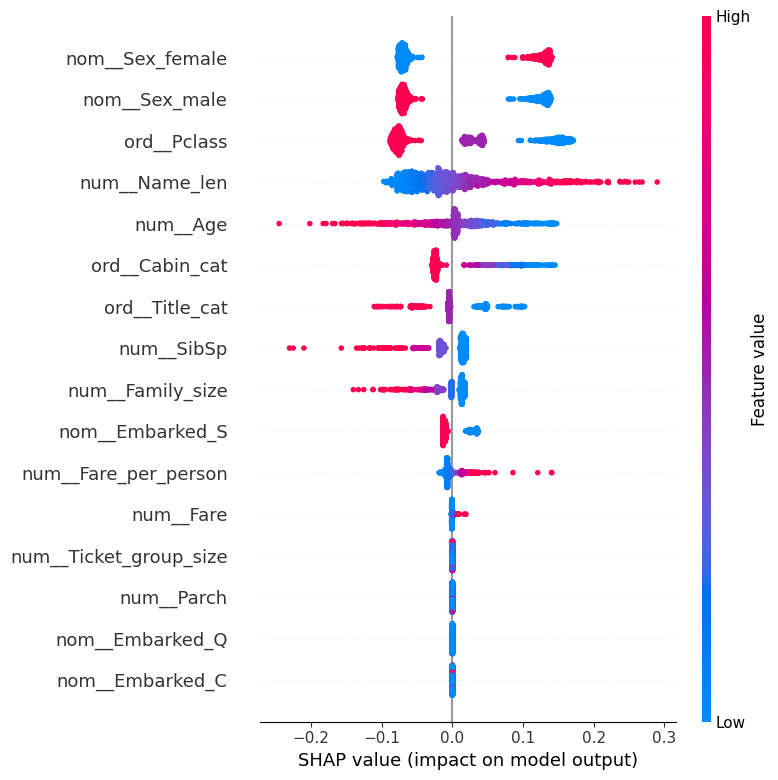

In [67]:
lr_shap_vals = excecute_shap(model_data=lr_b_model, features=f, target=t)

In [26]:
extract_shap_importance(lr_shap_vals)

,feature,mean_abs_shap
0,ord__Pclass,0.491405
1,nom__Sex_female,0.467813
2,nom__Sex_male,0.463274
3,num__Name_len,0.293927
4,num__Age,0.232918
5,ord__Cabin_cat,0.229319
6,num__SibSp,0.139481
7,ord__Title_cat,0.133922
8,num__Family_size,0.110000
9,nom__Embarked_S,0.102115


### Register model

In [27]:
model_registry.register(
        model_name="LogisticRegression_SAGA",
        best_parameters=lr_b_model["best_parameters"],
        pipeline=lr_b_model["best_pipeline"],
        metrics={
            "accuracy"  : lr_b_model["best_score"],
            "base_score": base_score
            }
        )
model_registry.show()

,model_name,best_parameters,accuracy,base_score
0,LogisticRegression_SAGA,"{'classifier__C': 0.1, 'classifier__l1_ratio': 0.5}",0.7969,0.8002


### Semi-conclusion
* **Core Mechanism**: The Linear Boundary
Logistic Regression solves binary classification by constructing a linear hyperplane. The model computes the linear projection of the feature vector onto the weight vector. The hard classification rule is strictly deterministic: a positive projection assigns class 1, and a negative projection assigns class 0. In this geometric sense, it operates identically to a linear perceptron.
* **The Probabilistic Shift**: Sigmoid and Log-Loss
Unlike margin-based classifiers, Logistic Regression does not output a raw geometric distance. Instead, it passes the linear projection through a sigmoid function, mapping the unbounded output into a strict probability between 0 and 1. The model is trained not by maximizing a safety margin, but by minimizing Binary Cross-Entropy (Log-Loss). This objective function optimizes the global probability distribution, heavily penalizing the model for highly confident misclassifications.
* **The Risk of No Margin and Regularization**
Because Logistic Regression lacks a geometric margin, it does not inherently ignore points far from the boundary; every data point influences the hyperplane's position. This makes the standard model highly sensitive to extreme outliers. To mitigate this risk, the algorithm employs L1 or L2 regularization (controlled by the inverse strength parameter $C$). Regularization constrains the magnitude of the weights, preventing any single feature or outlier from exerting disproportionate leverage. This weight constraint acts as a probabilistic substitute for a geometric margin, ensuring a stable and generalizable decision boundary.
---

## Support Vector Classifier (SVC)
### Overview

**Historical Context**
The foundational framework of Statistical Learning Theory was developed by Vladimir Vapnik and Alexey Chervonenkis in 1963. The modern Support Vector Machine, incorporating the soft margin and the kernel trick for non-linear classification, was formalized by Corinna Cortes and Vapnik in 1995, building upon the kernel method introduced by Boser, Guyon, and Vapnik in 1992.

**Mathematical Formulation**
Support Vector Classification seeks to find the optimal hyperplane that maximizes the geometric margin between distinct classes.

Let $\mathbf{x}_i \in \mathbb{R}^d$ be the feature vector and $y_i \in \{-1, 1\}$ be the corresponding class label. The primal optimization problem for the soft-margin SVM introduces slack variables $\xi_i \geq 0$ to accommodate non-linearly separable data:
$$ \min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{N} \xi_i $$
subject to the constraints:
$$ y_i(\mathbf{w}^T\mathbf{x}_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0 \quad \forall i $$
where $C > 0$ is the regularization parameter controlling the trade-off between maximizing the margin and minimizing the classification error.

By applying Lagrangian duality, the problem is transformed into its dual form, which depends exclusively on the dot products of the input vectors $\mathbf{x}_i^T\mathbf{x}_j$. The Kernel Trick substitutes these dot products with a kernel function $K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^T\phi(\mathbf{x}_j)$, implicitly mapping the data into a higher-dimensional feature space $\phi(\mathbf{x})$ to achieve non-linear separation without explicit computation of the coordinates.

Equivalently, this can be framed as Empirical Risk Minimization using the Hinge Loss function:
$$ \mathcal{L}(\mathbf{w}, b) = \frac{1}{N} \sum_{i=1}^{N} \max(0, 1 - y_i(\mathbf{w}^T\mathbf{x}_i + b)) + \lambda \|\mathbf{w}\|^2 $$
where $\lambda = \frac{1}{2C}$. The hinge loss penalizes misclassifications and points falling within the margin, enforcing the structural risk minimization principle inherent to the SVM framework.


### Feature Engineering & Selection Rationale

1. Continuous vs. Discretized Features
Support Vector Machines rely on distance metrics (e.g., Euclidean distance in the RBF kernel) to construct the decision boundary. Binning continuous variables (e.g., `Age` into `Age_cat`, or `Fare_per_person` into `Fare_per_person_cat`) destroys intra-bin variance and introduces arbitrary, hard decision boundaries. This degrades the kernel's ability to map smooth, non-linear manifolds.
**Decision:** Retain continuous features in their original scaled form. Discard all discretized counterparts (`*_cat` features derived from continuous variables).

2. Multicollinearity and Feature Redundancy
SVM optimization solves a convex quadratic programming problem. Exact or near-exact multicollinearity can cause numerical instability in the solver and inflate the variance of the decision boundary.
* `Family_size` is an exact linear combination of `SibSp` and `Parch` ($X_{family} = X_{sibsp} + X_{parch} + 1$). The constituent columns must be dropped.
* `Fare` is highly collinear with `Fare_per_person` and `Ticket_group_size`. `Fare_per_person` is retained as it normalizes for group size, providing a more accurate, independent proxy for individual socio-economic status.

3. Categorical Encoding Strategy (Nominal vs. Ordinal)
For distance-based algorithms utilizing the Radial Basis Function (RBF) kernel, the distinction between nominal and ordinal categorical features is mathematically obsolete and potentially detrimental.
The RBF kernel computes similarity based on Euclidean distance: $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$. If an ordinal encoding (e.g., mapping categories to $1, 2, 3$) is applied, the algorithm assumes a strict linear metric between categories. This imposes an artificial geometric constraint, forcing the decision boundary to be parallel to the encoded axis and destroying the orthogonality of the categories.

    **Decision:** One-Hot Encoding maps all categorical variables to orthogonal vertices of a high-dimensional hypercube. This preserves the true categorical nature of the data, allowing the SVM to construct non-linear margins without assuming arbitrary linear distances between discrete states. The feature partition is reduced to exactly two types: Numeric and Categorical.

4. Final Feature Partition
The feature space is strictly partitioned into two distinct groups for the preprocessing pipeline:

    **Numeric Features:**
`Age`, `Fare_per_person`, `Family_size`, `Ticket_group_size`, `Name_len`. -> **Preprocessing:** Median imputation (structural safeguard) followed by Standard Scaling to ensure the margin is not dominated by features with larger variances.

    **Categorical Features:**
`Pclass`, `Sex`, `Embarked`, `Title_cat`, `Cabin_cat`. -> **Preprocessing:** Most frequent imputation followed by One-Hot Encoding to ensure orthogonal representation in the kernel space.

### Functions

In [37]:
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

In [38]:
def define_svc_feature_subsets(
        numeric_features: List[str],
        categorical_features: List[str]
        ) -> Dict[str, List[str]]:
    return {
        "numeric_features"    : numeric_features,
        "categorical_features": categorical_features,
    }


def build_svc_preprocessor(features: Dict[str, List[str]]) -> ColumnTransformer:
    numeric_transformer = Pipeline(
            steps=[("scaler", StandardScaler())]
            )
    categorical_transformer = Pipeline(
            steps=[("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]
            )

    preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, features["numeric_features"]),
                ("cat", categorical_transformer, features["categorical_features"])]
            )
    return preprocessor


def build_svc_pipeline(preprocessor: ColumnTransformer) -> Pipeline:
    base_classifier = SVC(
            C=1.0,
            kernel="rbf",
            gamma="scale",
            random_state=42
            )

    calibrated_classifier = CalibratedClassifierCV(
            estimator=base_classifier,
            method="sigmoid",
            ensemble=False,
            cv=5
            )

    pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", calibrated_classifier)
                ]
            )
    return pipeline

### Baseline prediction

In [68]:
features = define_svc_feature_subsets(
        numeric_features=["Age", "Family_size", "Ticket_group_size", "Fare_per_person", "Name_len"],
        categorical_features=["Sex", "Embarked", "Pclass", "Title_cat", "Cabin_cat"]
        )

f, t = prepare_features_and_target(train_df, "Survived", features)
svc_preprocessor = build_svc_preprocessor(features)
svc_pipeline = build_svc_pipeline(svc_preprocessor)
base_score = train_and_evaluate_model(svc_pipeline, f, t)
print(f"Base score: {base_score:.4f}")

Base score: 0.8328


### Tune hyperparameters

In [69]:
def define_svc_search_space(
        classifier_c: List[float] | None = None,
        classifier_gamma: List[float | str] | None = None
        ) -> Dict[str, List[Any]]:
    if classifier_c is None:
        classifier_c = [0.1, 1.0, 10.0, 100.0]
    if classifier_gamma is None:
        classifier_gamma = ["scale", "auto", 0.01, 0.1, 1.0]

    search_space: Dict[str, List[Any]] = {
        "classifier__estimator__C"    : classifier_c,
        "classifier__estimator__gamma": classifier_gamma,
    }
    return search_space


def tune_svc_hyperparameters(
        pipeline: Pipeline,
        feature_matrix: pd.DataFrame,
        target_vector: pd.Series,
        search_space: Dict[str, List[Any]],
        cross_validator: BaseCrossValidator,
        scoring: str = "accuracy"
        ) -> Dict[str, Any]:
    grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=search_space,
            scoring=scoring,
            cv=cross_validator,
            n_jobs=-1,
            refit=True,
            error_score="raise"
            )

    grid_search.fit(feature_matrix, target_vector)

    return {
        "best_pipeline"  : grid_search.best_estimator_,
        "best_parameters": grid_search.best_params_,
        "best_score"     : float(grid_search.best_score_)
    }

In [70]:
svc_b_model = tune_svc_hyperparameters(
        svc_pipeline, f, t, define_svc_search_space(), StratifiedKFold()
        )

print(f"Best score: {svc_b_model['best_score']:.4f}")

Best score: 0.8384


### SHAP analysis

PermutationExplainer explainer: 101it [00:29,  2.44it/s]                         


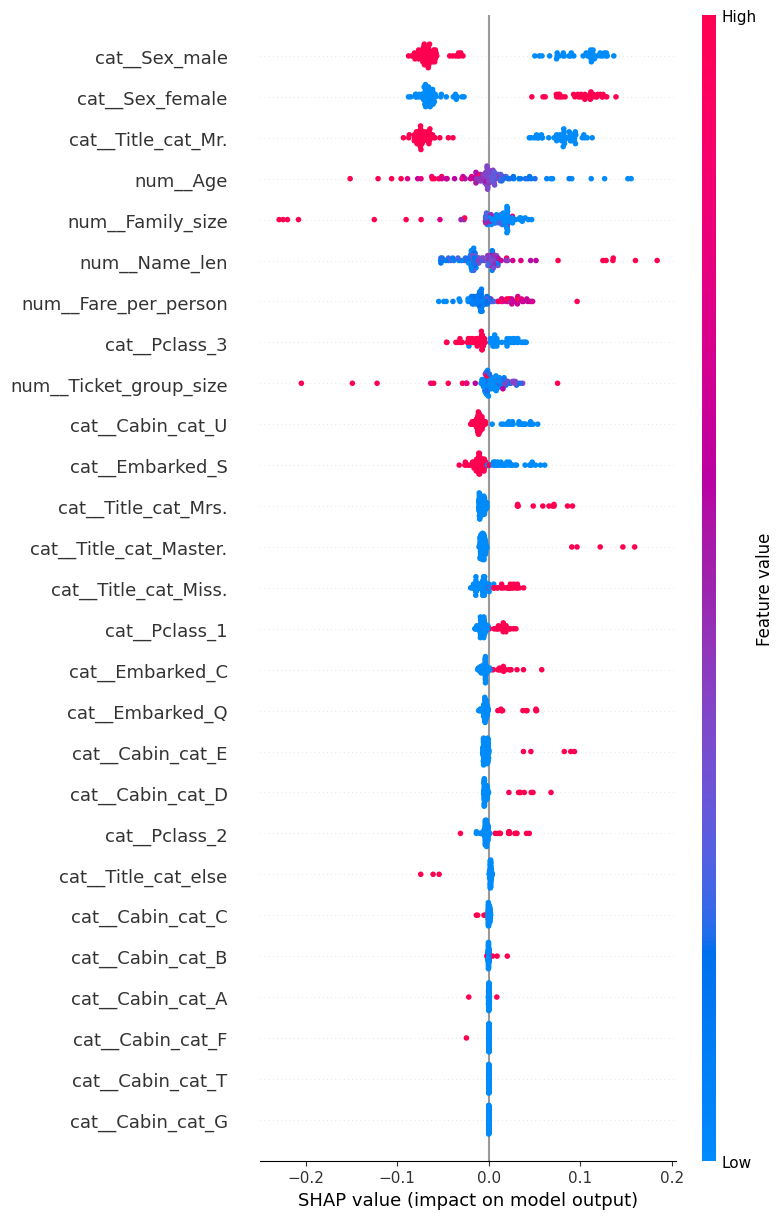

In [72]:
svc_shap_vals = excecute_shap(model_data=svc_b_model, features=f, target=t)

### Registry model

In [73]:
model_registry.register(
        model_name="SVC",
        best_parameters=svc_b_model["best_parameters"],
        pipeline=svc_b_model["best_pipeline"],
        metrics={
            "accuracy"  : svc_b_model["best_score"],
            "base_score": base_score
            }
        )
model_registry.show()

,model_name,best_parameters,accuracy,base_score
1,SVC,"{'classifier__estimator__C': 1.0, 'classifier__estimator__gamma': 'scale'}",0.8384,0.8328
0,LogisticRegression_SAGA,"{'classifier__C': 0.1, 'classifier__l1_ratio': 0.5}",0.7969,0.8002


### Semi-conclusion
* **Core Mechanism**: The Maximum Margin Hyperplane
Unlike models that consider every data point to draw a boundary, the Support Vector Classifier seeks the "widest possible street" that separates the classes. The decision boundary is placed exactly in the center of this street. Crucially, the model's geometry is defined entirely by the data points that lie on the edges of the street—these are the "support vectors." Points located far from the boundary have zero influence on the model, making the algorithm inherently focused only on the most difficult, borderline cases.

* **The Kernel Trick**: Non-Linear Separation
When data cannot be separated by a flat plane in the original feature space, the SVC employs the "Kernel Trick." Instead of explicitly calculating new, complex coordinates, it uses a mathematical function (such as the Radial Basis Function) to measure the similarity between points as if they were projected into a much higher-dimensional space. This allows the algorithm to construct complex, non-linear decision boundaries in the original space without ever performing the computationally expensive coordinate transformations directly.

* **The Soft Margin and Regularization**: The $C$ Parameter
Real-world data is rarely perfectly separable, and outliers are inevitable. The SVC addresses this by introducing a "soft margin," which allows some data points to cross the street boundaries or even the center line. This flexibility is governed by the regularization parameter $C$. A small $C$ creates a wider street, tolerating more misclassifications to achieve a smoother, more generalized boundary. Conversely, a large $C$ creates a narrow, strict street, heavily penalizing any point that falls inside the margin, which risks overfitting to the noise and outliers of the training set.
---

## K-Nearest Neighbors (KNN)
### Overview

**Historical Context**
The K-Nearest Neighbors algorithm was originally introduced by Evelyn Fix and Joseph Hodges in 1951 as a non-parametric method for discriminant analysis. It was later formalized for statistical pattern recognition and remains one of the foundational algorithms in machine learning due to its intuitive, instance-based learning paradigm.

**Mathematical Formulation**
K-Nearest Neighbors is a lazy, instance-based learning algorithm that classifies a query point based on the majority class of its $k$ closest training examples in the feature space.

Let $\mathbf{x}_q \in \mathbb{R}^d$ be the query feature vector, and $\mathcal{D} = \{(\mathbf{x}_1, y_1), \dots, (\mathbf{x}_N, y_N)\}$ be the training dataset. The algorithm first computes the distance between the query point and all training instances using a distance metric, typically the Minkowski distance:
$$ D(\mathbf{x}_q, \mathbf{x}_i) = \left( \sum_{j=1}^{d} |x_{q,j} - x_{i,j}|^p \right)^{1/p} $$
where $p=2$ corresponds to the standard Euclidean distance.

The algorithm then identifies the subset $\mathcal{N}_k(\mathbf{x}_q) \subset \mathcal{D}$ containing the $k$ training instances with the smallest distances to $\mathbf{x}_q$.

The predicted class label $\hat{y}_q$ is determined by a majority vote among the labels of these $k$ neighbors:
$$ \hat{y}_q = \arg\max_{c} \sum_{(\mathbf{x}_i, y_i) \in \mathcal{N}_k(\mathbf{x}_q)} \mathbb{I}(y_i = c) $$
where $\mathbb{I}(\cdot)$ is the indicator function, and $c$ represents a possible class label.

Optionally, the voting can be weighted by the inverse of the distance to give closer neighbors more influence:
$$ \hat{y}_q = \arg\max_{c} \sum_{(\mathbf{x}_i, y_i) \in \mathcal{N}_k(\mathbf{x}_q)} w_i \mathbb{I}(y_i = c), \quad \text{where } w_i = \frac{1}{D(\mathbf{x}_q, \mathbf{x}_i)} $$

This formulation highlights that KNN does not learn an explicit global decision boundary during training; instead, it constructs local, non-linear boundaries implicitly at inference time based strictly on the geometric distribution of the training data.

### Feature Engineering & Selection Rationale

1. Continuous vs. Discretized Features
K-Nearest Neighbors classifies instances based on their geometric proximity to training examples in the feature space. Binning continuous variables (e.g., transforming `Age` into `Age_cat`) collapses the continuous distance metric into discrete, arbitrary steps. Two passengers aged 20 and 29 would have a distance of zero if placed in the same bin, destroying the algorithm's ability to recognize fine-grained similarities.
* **Decision:** Retain continuous features in their original scaled form to preserve the continuous, granular distance relationships. Discretized counterparts are excluded.

2. Multicollinearity and Distance Inflation
In distance-based algorithms, every feature dimension contributes additively to the total distance calculation. Including linearly dependent or highly correlated features artificially inflates the "weight" of that underlying concept in the distance metric.
* `Family_size` is an exact linear combination of `SibSp` and `Parch`. Including all three gives the concept of "family" triple the influence on the distance calculation compared to a single independent feature. The derived column is dropped.
* `Fare` and `Fare_per_person` are highly correlated. To prevent redundant distance contributions, the raw `Fare` is dropped in favor of the normalized `Fare_per_person`.

3. Categorical Encoding Strategy (Nominal vs. Ordinal)
KNN requires all inputs to be numerical to compute geometric distances. The encoding strategy must align with the mathematical nature of the categories:
* **Ordinal Features:** Categories with a strict, monotonic relationship (e.g., `Pclass`). Mapping these to integers (1, 2, 3) is mathematically ideal for KNN, as the Euclidean distance will correctly reflect that 3rd class is further from 1st class than 2nd class is.
* **Nominal Features:** Categories without inherent ordering (e.g., `Embarked`). Assigning integers to these would impose a false geometric distance. These must be One-Hot Encoded to create orthogonal binary dimensions, ensuring that the distance between any two distinct categories is uniform.

4. Final Feature Partition
The feature space is partitioned into three distinct groups for the preprocessing pipeline:

    * **Numeric Features:**
`Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len`.

        **Preprocessing:** Median imputation followed by Standard Scaling. **Scaling is mathematically critical for KNN.** Because KNN relies on Euclidean distance, features with larger natural ranges (e.g., `Fare_per_person`) would completely dominate the distance calculation over features with smaller ranges (e.g., `Age`). Standardization ensures each feature contributes equally to the proximity metric.

    * **Ordinal Categorical Features:**
`Pclass`.

        **Preprocessing:** Ordinal Encoding to map the inherent hierarchy into integers, preserving the monotonic distance relationships.

    * **Nominal Categorical Features:**
`Sex`, `Embarked`, `Title_cat`, `Cabin_cat`.

        **Preprocessing:** One-Hot Encoding to generate orthogonal binary indicators, preventing the algorithm from assuming false geometric distances between unordered categories.

### Functions

In [79]:
from sklearn.neighbors import KNeighborsClassifier

In [80]:
def define_knn_feature_subsets(
        numeric_features: List[str],
        nominal_categorical_features: List[str],
        ordinal_categorical_features: List[str]
        ) -> Dict[str, List[str]]:
    return {
        "numeric_features"            : numeric_features,
        "nominal_categorical_features": nominal_categorical_features,
        "ordinal_features"            : ordinal_categorical_features,
        }


def build_knn_preprocessor(features: Dict[str, List[str]]) -> ColumnTransformer:
    numeric_transformer = Pipeline(
            steps=[
                ("scaler", StandardScaler())
                ]
            )

    nominal_transformer = Pipeline(
            steps=[
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
                ]
            )

    ordinal_transformer = Pipeline(
            steps=[
                ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
                ]
            )

    preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, features["numeric_features"]),
                ("nom", nominal_transformer, features["nominal_categorical_features"]),
                ("ord", ordinal_transformer, features["ordinal_features"]),
                ]
            )
    return preprocessor


def build_knn_pipeline(preprocessor: ColumnTransformer) -> Pipeline:
    classifier = KNeighborsClassifier(
            n_neighbors=5,
            weights="uniform",
            algorithm="auto",
            p=2,
            n_jobs=-1
            )

    pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", classifier)
                ]
            )
    return pipeline

### Base prediction

In [81]:
features = define_knn_feature_subsets(
        numeric_features=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
        nominal_categorical_features=["Sex", "Embarked", "Title_cat", "Cabin_cat"],
        ordinal_categorical_features=["Pclass"]
        )

f, t = prepare_features_and_target(train_df, "Survived", features)
knn_preprocessor = build_knn_preprocessor(features)
knn_pipeline = build_knn_pipeline(knn_preprocessor)
base_score = train_and_evaluate_model(knn_pipeline, f, t)
print(f"Base score: {base_score:.4f}")

Base score: 0.8283


### Tune hyperparameters

In [83]:
def define_knn_search_space(
        classifier_n_neighbors: List[int] | None = None,
        classifier_weights: List[str] | None = None,
        classifier_p: List[int] | None = None
        ) -> Dict[str, List[Any]]:
    if classifier_n_neighbors is None:
        classifier_n_neighbors = [3, 5, 7, 9, 11, 15, 21]
    if classifier_weights is None:
        classifier_weights = ["uniform", "distance"]
    if classifier_p is None:
        classifier_p = [1, 2]

    search_space: Dict[str, List[Any]] = {
        "classifier__n_neighbors": classifier_n_neighbors,
        "classifier__weights"    : classifier_weights,
        "classifier__p"          : classifier_p,
    }
    return search_space


def tune_knn_hyperparameters(
        pipeline: Pipeline,
        feature_matrix: pd.DataFrame,
        target_vector: pd.Series,
        search_space: Dict[str, List[Any]],
        cross_validator: BaseCrossValidator,
        scoring: str = "accuracy"
        ) -> Dict[str, Any]:
    grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=search_space,
            scoring=scoring,
            cv=cross_validator,
            n_jobs=-1,
            refit=True,
            error_score="raise"
            )

    grid_search.fit(feature_matrix, target_vector)

    return {
        "best_pipeline"  : grid_search.best_estimator_,
        "best_parameters": grid_search.best_params_,
        "best_score"     : float(grid_search.best_score_)
        }

In [84]:
knn_b_model = tune_knn_hyperparameters(
        knn_pipeline, f, t, define_knn_search_space(), StratifiedKFold()
        )

print(f"Best score: {knn_b_model['best_score']:.4f}")

Best score: 0.8339


### SHAP analysis

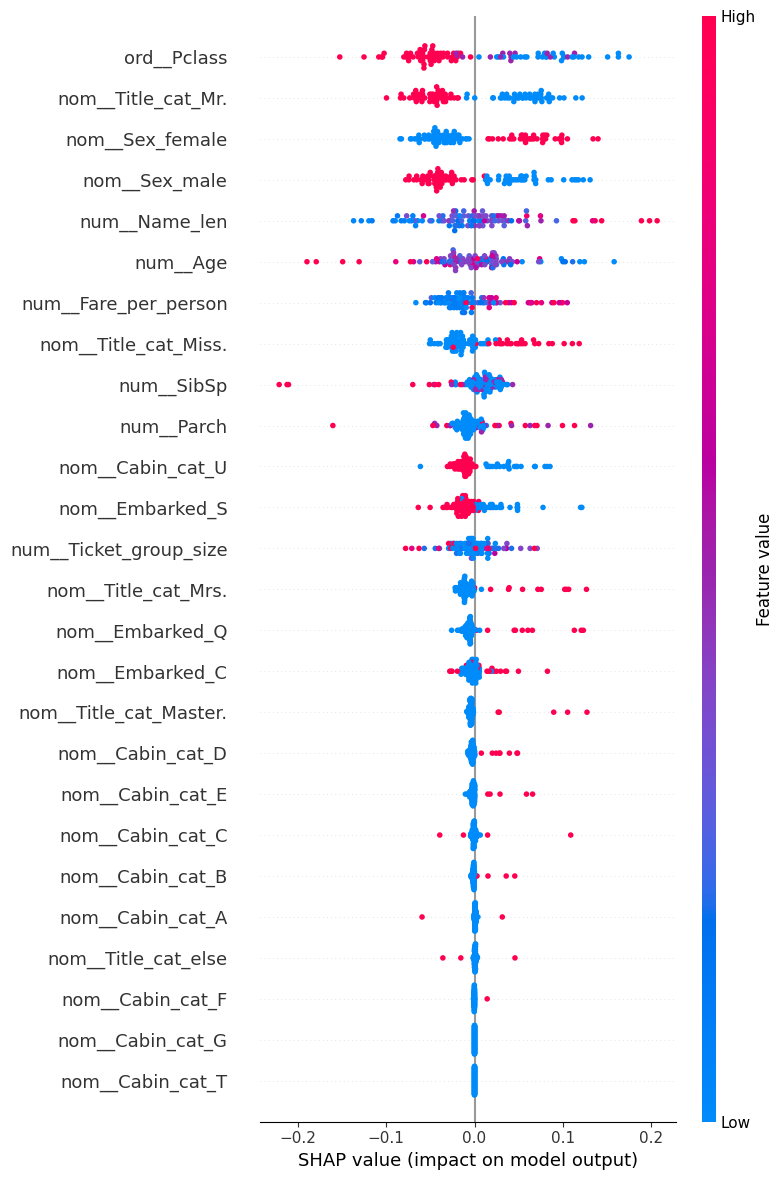

In [85]:
knn_shap_values = excecute_shap(knn_b_model, f, t)

### Registry model

In [86]:
model_registry.register(
        model_name="KNN",
        best_parameters=knn_b_model["best_parameters"],
        pipeline=knn_b_model["best_pipeline"],
        metrics={
            "accuracy"  : knn_b_model["best_score"],
            "base_score": base_score
            }
        )
model_registry.show()

,model_name,best_parameters,accuracy,base_score
1,SVC,"{'classifier__estimator__C': 1.0, 'classifier__estimator__gamma': 'scale'}",0.8384,0.8328
2,KNN,"{'classifier__n_neighbors': 5, 'classifier__p': 1, 'classifier__weights': 'uniform'}",0.8339,0.8283
0,LogisticRegression_SAGA,"{'classifier__C': 0.1, 'classifier__l1_ratio': 0.5}",0.7969,0.8002


### Semi-conclusion
* **Core Mechanism**: Instance-Based "Lazy" Learning
Unlike models that construct a global mathematical equation or hyperplane during training, K-Nearest Neighbors is a "lazy" learner. It performs no explicit optimization phase; instead, it memorizes the entire training dataset. The actual computation—measuring distances to existing points and aggregating their labels—occurs entirely at inference time.

* **The Geometry of Similarity**: Distance Metrics and Scaling
KNN classifies a query point based on its physical proximity to training examples in the feature space, typically measured using Euclidean distance. Because it relies on raw geometric distance, it is highly sensitive to the scale of the features. If one feature has a much larger numerical range than another, it will artificially dominate the distance calculation, making strict feature scaling mathematically mandatory.

* **The Bias-Variance Trade-off**: The $k$ Parameter
The hyperparameter $k$ dictates the number of neighbors consulted to make a prediction, directly controlling the model's complexity. A small $k$ (e.g., $k=1$) creates a highly complex, jagged decision boundary that captures noise, leading to high variance and overfitting. Conversely, a large $k$ smooths the decision boundary, increasing bias and risking underfitting by ignoring local patterns. Tuning $k$ is a direct exercise in balancing this fundamental trade-off.
---

## Linear Discriminant Analysis (LDA)
### Overview

**Historical Context**
Linear Discriminant Analysis was originally formulated by Ronald A. Fisher in 1936 in his seminal paper, *The Use of Multiple Measurements in Taxonomic Problems*, as a method for dimensionality reduction and classification. It was later generalized for multi-class problems and formally integrated into the broader framework of statistical pattern recognition and generative probabilistic modeling.

**Mathematical Formulation**
Linear Discriminant Analysis is a generative classification algorithm that models the class-conditional densities to construct linear decision boundaries. It operates under the strict assumption that the features within each class are drawn from a multivariate Gaussian distribution and that all classes share an identical covariance matrix (homoscedasticity).

Let $\mathbf{x} \in \mathbb{R}^d$ be the feature vector and $y \in \{1, \dots, C\}$ be the class label. Assuming $P(\mathbf{x}|y=c) \sim \mathcal{N}(\boldsymbol{\mu}_c, \boldsymbol{\Sigma})$, the discriminant function for class $c$ is derived by taking the logarithm of the posterior probability via Bayes' theorem:
$$ \delta_c(\mathbf{x}) = \mathbf{x}^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_c - \frac{1}{2} \boldsymbol{\mu}_c^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_c + \log P(y=c) $$

The predicted class is determined by selecting the class with the maximum discriminant score:
$$ \hat{y} = \arg\max_{c} \delta_c(\mathbf{x}) $$

Equivalently, from a geometric perspective, Fisher's Linear Discriminant seeks a projection vector $\mathbf{w}$ that maximizes the separability between classes. This is achieved by maximizing the Rayleigh quotient, which is the ratio of the between-class variance to the within-class variance:
$$ J(\mathbf{w}) = \frac{\mathbf{w}^T \mathbf{S}_B \mathbf{w}}{\mathbf{w}^T \mathbf{S}_W \mathbf{w}} $$
where $\mathbf{S}_B = \sum_{c=1}^{C} N_c (\boldsymbol{\mu}_c - \boldsymbol{\mu})(\boldsymbol{\mu}_c - \boldsymbol{\mu})^T$ is the between-class scatter matrix, and $\mathbf{S}_W = \sum_{c=1}^{C} \sum_{\mathbf{x}_i \in c} (\mathbf{x}_i - \boldsymbol{\mu}_c)(\mathbf{x}_i - \boldsymbol{\mu}_c)^T$ is the within-class scatter matrix.

The optimal projection vector $\mathbf{w}$ is analytically solved as the eigenvector corresponding to the largest eigenvalue of the matrix $\mathbf{S}_W^{-1} \mathbf{S}_B$. This dual formulation highlights that LDA constructs linear boundaries by explicitly modeling the underlying probability distributions, making it highly sensitive to violations of the Gaussian and equal-covariance assumptions.

### Feature Engineering & Selection Rationale

1. Continuous vs. Discretized Features
Linear Discriminant Analysis explicitly models the class-conditional probability densities under the assumption that features follow a multivariate Gaussian distribution. Binning continuous variables (e.g., transforming `Age` into `Age_cat`) destroys the continuous variance structure and violates the Gaussian assumption, preventing the algorithm from accurately estimating class means and covariances.
* **Decision:** Retain continuous features in their original scaled form to preserve the granular variance required for accurate distribution modeling. Discretized counterparts are excluded.

2. Multicollinearity and the Scatter Matrix
LDA constructs its decision boundary by computing the inverse of the within-class scatter matrix ($\mathbf{S}_W$). Exact multicollinearity renders $\mathbf{S}_W$ singular (non-invertible), causing the optimization to fail entirely. Near multicollinearity makes the matrix ill-conditioned, leading to extreme numerical instability and inflated variance in the discriminant vectors.
* `Family_size` is an exact linear combination of `SibSp` and `Parch`. Including all three guarantees a singular $\mathbf{S}_W$ matrix. The derived column must be dropped.
* `Fare` and `Fare_per_person` are highly correlated. To maintain matrix conditioning and numerical stability, the raw `Fare` is dropped in favor of the normalized `Fare_per_person`, which provides a more stable proxy for individual socio-economic status.

3. Categorical Encoding Strategy (Nominal vs. Ordinal)
LDA is designed for continuous variables. When incorporating categorical data, the encoding strategy must minimize the introduction of spurious dimensions that could degrade the covariance matrix estimation, especially in smaller datasets like Titanic.
* **Ordinal Features:** Categories with a strict, monotonic relationship (e.g., `Pclass`, `Title_cat`, `Cabin_cat`). Mapping these to a single integer sequence is highly preferred. It consumes only one degree of freedom, preserving the stability of the scatter matrix inversion while reasonably approximating a continuous gradient.
* **Nominal Features:** Categories without inherent ordering (e.g., `Sex`, `Embarked`). These must be One-Hot Encoded to create orthogonal binary indicators. While binary features technically violate the Gaussian assumption, One-Hot Encoding is the standard, least-damaging workaround to prevent the model from assuming false geometric distances between unordered categories.

4. Final Feature Partition
The feature space is partitioned into three distinct groups for the preprocessing pipeline:

    * **Numeric Features:**
`Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len`.
        **Preprocessing:** Median imputation followed by Standard Scaling. While LDA is theoretically affine-invariant (making scaling mathematically optional for the final boundary), scaling is critically important in practice to prevent numerical underflow/overflow during the inversion of $\mathbf{S}_W$ and to ensure stable covariance estimation across features with vastly different natural ranges.

    * **Ordinal Categorical Features:**
`Pclass`, `Title_cat`, `Cabin_cat`.
        **Preprocessing:** Ordinal Encoding to map inherent hierarchies into a single monotonic integer feature, conserving degrees of freedom.

    * **Nominal Categorical Features:**
`Sex`, `Embarked`.
        **Preprocessing:** One-Hot Encoding to generate orthogonal binary indicators, preserving the distinct identity of each category without imposing artificial ordinal distances.

### Functions

In [96]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


def define_lda_feature_subsets(
        numeric_features: List[str],
        nominal_categorical_features: List[str],
        ordinal_categorical_features: List[str]
        ) -> Dict[str, List[str]]:
    return {
        "numeric_features"            : numeric_features,
        "nominal_categorical_features": nominal_categorical_features,
        "ordinal_features"            : ordinal_categorical_features,
    }


def build_lda_preprocessor(features: Dict[str, List[str]]) -> ColumnTransformer:
    numeric_transformer = Pipeline(
            steps=[
                ("scaler", StandardScaler())
                ]
            )

    nominal_transformer = Pipeline(
            steps=[
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
                ]
            )

    ordinal_transformer = Pipeline(
            steps=[
                ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
                ]
            )

    preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, features["numeric_features"]),
                ("nom", nominal_transformer, features["nominal_categorical_features"]),
                ("ord", ordinal_transformer, features["ordinal_features"]),
                ]
            )
    return preprocessor


def build_lda_pipeline(preprocessor: ColumnTransformer) -> Pipeline:
    classifier = LinearDiscriminantAnalysis(
            solver="svd",
            shrinkage=None
            )

    pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", classifier)
                ]
            )
    return pipeline

### Base prediction

In [100]:
features = define_lda_feature_subsets(
        numeric_features=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
        nominal_categorical_features=["Sex", "Embarked"],
        ordinal_categorical_features=["Pclass", "Title_cat", "Cabin_cat"]
        )

f, t = prepare_features_and_target(train_df, "Survived", features)
lda_preprocessor = build_lda_preprocessor(features)
lda_pipeline = build_lda_pipeline(lda_preprocessor)
base_score = train_and_evaluate_model(lda_pipeline, f, t)
print(f"Base score: {base_score:.4f}")

Base score: 0.7890


### Tune hyperparameters

In [102]:
def define_lda_search_space() -> List[Dict[str, List[Any]]]:
    return [
        {
            "classifier__solver"   : ["svd"],
            "classifier__shrinkage": [None],
            }
        ]


def tune_lda_hyperparameters(
        pipeline: Pipeline,
        feature_matrix: pd.DataFrame,
        target_vector: pd.Series,
        search_space: List[Dict[str, List[Any]]],
        cross_validator: BaseCrossValidator,
        scoring: str = "accuracy"
        ) -> Dict[str, Any]:
    grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=search_space,
            scoring=scoring,
            cv=cross_validator,
            n_jobs=-1,
            refit=True,
            error_score="raise"
            )

    grid_search.fit(feature_matrix, target_vector)

    return {
        "best_pipeline"  : grid_search.best_estimator_,
        "best_parameters": grid_search.best_params_,
        "best_score"     : float(grid_search.best_score_)
    }

In [103]:
lda_b_model = tune_lda_hyperparameters(
        lda_pipeline, f, t, define_lda_search_space(), StratifiedKFold()
        )

print(f"Best score: {lda_b_model['best_score']:.4f}")

Best score: 0.7912


### SHAP analysis

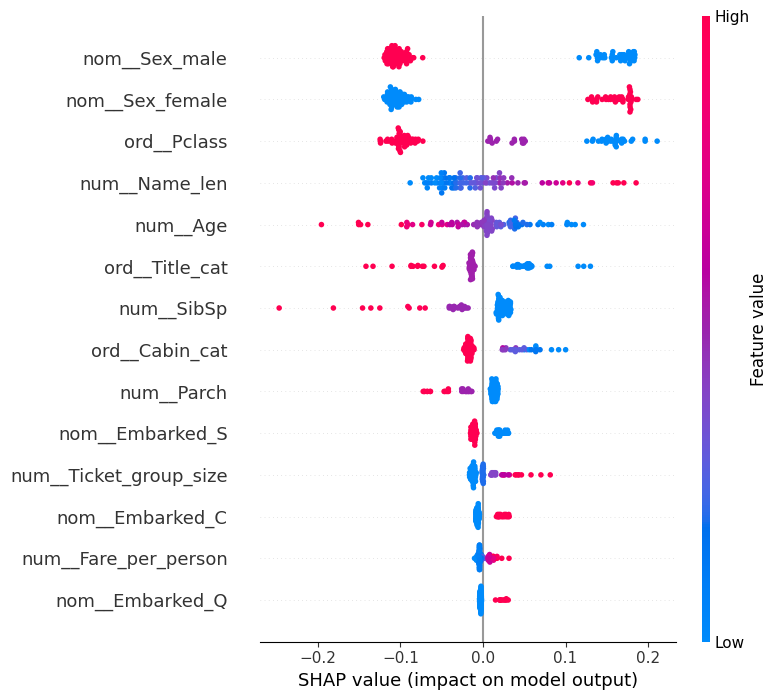

In [104]:
lda_values = excecute_shap(lda_b_model, f, t)

### Registry model

In [105]:
model_registry.register(
        model_name="LDA",
        best_parameters=lda_b_model["best_parameters"],
        pipeline=lda_b_model["best_pipeline"],
        metrics={
            "accuracy"  : lda_b_model["best_score"],
            "base_score": base_score
            }
        )
model_registry.show()

,model_name,best_parameters,accuracy,base_score
1,SVC,"{'classifier__estimator__C': 1.0, 'classifier__estimator__gamma': 'scale'}",0.8384,0.8328
2,KNN,"{'classifier__n_neighbors': 5, 'classifier__p': 1, 'classifier__weights': 'uniform'}",0.8339,0.8283
0,LogisticRegression_SAGA,"{'classifier__C': 0.1, 'classifier__l1_ratio': 0.5}",0.7969,0.8002
3,LDA,"{'classifier__shrinkage': None, 'classifier__solver': 'svd'}",0.7912,0.7890


### Semi-conclusion
* **Core Mechanism**: Maximizing Class Separability
Unlike discriminative models that attempt to draw a boundary directly between classes, Linear Discriminant Analysis is a generative approach that seeks to project the data to maximize the distance between class means while minimizing the variance within each individual class. It achieves this by optimizing the Rayleigh quotient—the mathematical ratio of between-class scatter to within-class scatter.

* **The Probabilistic Foundation**: Gaussian Assumptions
LDA mathematically models the distribution of features within each class as a multivariate Gaussian distribution and applies Bayes' theorem to estimate posterior probabilities. This generative nature allows it to handle multi-class problems naturally and provides a probabilistic interpretation, but it strictly relies on the assumption that the data within each class follows a normal distribution.

* **The Linearity Constraint**: Homoscedasticity
The defining characteristic of LDA is its strict assumption that all classes share an identical covariance matrix (homoscedasticity). Because the shared covariance matrices cancel out during the derivation of the decision boundary, the resulting boundary is strictly linear. If this assumption is violated—meaning classes have significantly different variances—the linear boundary will fail to capture the true geometry of the data, necessitating a transition to Quadratic Discriminant Analysis (QDA).
---

## Gaussian Naive Bayes (GNB)
### Overview

**Historical Context**
The algorithm is rooted in Bayes' Theorem, formulated by Thomas Bayes in 1763 and published posthumously by Richard Price. Pierre-Simon Laplace later formalized the mathematical framework in 1812, applying it to probability and celestial mechanics. The "naive" conditional independence assumption, which simplifies the joint probability calculation, was introduced to machine learning and document classification by Marvin Minsky and colleagues in the 1960s. The Gaussian variant specifically adapts this framework for continuous variables by assuming a normal distribution.

**Mathematical Formulation**
Gaussian Naive Bayes is a generative probabilistic classifier that models the distribution of each feature independently within each class.

The foundation is Bayes' Theorem, which calculates the posterior probability of a class $c$ given a feature vector $\mathbf{x} \in \mathbb{R}^d$:
$$ P(Y=c|\mathbf{x}) = \frac{P(\mathbf{x}|Y=c)P(Y=c)}{P(\mathbf{x})} $$

The "naive" assumption posits that all features are conditionally independent given the class label. This simplifies the joint likelihood $P(\mathbf{x}|Y=c)$ into the product of marginal probabilities:
$$ P(\mathbf{x}|Y=c) = \prod_{i=1}^{d} P(x_i|Y=c) $$

For continuous features, the Gaussian Naive Bayes model assumes that $P(x_i|Y=c)$ follows a normal (Gaussian) distribution parameterized by the class-specific mean $\mu_{c,i}$ and variance $\sigma_{c,i}^2$:
$$ P(x_i|Y=c) = \frac{1}{\sqrt{2\pi\sigma_{c,i}^2}} \exp\left(-\frac{(x_i - \mu_{c,i})^2}{2\sigma_{c,i}^2}\right) $$

The predicted class $\hat{y}$ is determined by selecting the class that maximizes the posterior probability. Since the denominator $P(\mathbf{x})$ is constant for all classes, it is omitted during maximization:
$$ \hat{y} = \arg\max_{c} P(Y=c) \prod_{i=1}^{d} P(x_i|Y=c) $$

To prevent numerical underflow caused by multiplying many small probabilities, the computation is transformed into log-space. The classification rule becomes:
$$ \hat{y} = \arg\max_{c} \left[ \log P(Y=c) - \frac{1}{2} \sum_{i=1}^{d} \left( \log(2\pi\sigma_{c,i}^2) + \frac{(x_i - \mu_{c,i})^2}{\sigma_{c,i}^2} \right) \right] $$

This formulation highlights that GNB estimates the parameters ($\mu$ and $\sigma^2$) directly from the training data via Maximum Likelihood Estimation, requiring no iterative optimization or gradient descent, making it exceptionally fast and highly scalable.

### Feature Engineering & Selection Rationale

1. Continuous vs. Discretized Features
Gaussian Naive Bayes models the probability density of each feature by explicitly calculating its mean ($\mu$) and variance ($\sigma^2$) under a continuous Gaussian (Normal) distribution. Binning continuous variables (e.g., transforming `Age` into `Age_cat`) destroys this continuous distribution, forcing the algorithm to calculate the mean and variance of discrete, arbitrary bins. This severely distorts the likelihood calculations and violates the core Gaussian assumption.
* **Decision:** Retain continuous features in their original form to preserve the granular variance required for accurate probability density estimation. Discretized counterparts are excluded.

2. The "Naive" Independence Assumption and Multicollinearity
The foundational mathematical assumption of this algorithm is that all features are *conditionally independent* given the class label. When features are highly correlated, this assumption is severely violated. The model will effectively "double-count" the same underlying evidence, artificially inflating the posterior probabilities and leading to overconfident, unstable predictions.
* `Family_size` is an exact linear combination of `SibSp` and `Parch`. Including it guarantees that the "family" evidence is counted twice. The derived column must be dropped.
* `Fare` and `Fare_per_person` are highly correlated. To prevent redundant evidence inflation, the raw `Fare` is dropped in favor of the normalized `Fare_per_person`.

3. Categorical Encoding Strategy (Nominal vs. Ordinal)
Because GNB is inherently designed for continuous variables, applying it to categorical data requires an encoding strategy that prevents the model from assuming false mathematical relationships.
* **Ordinal Features:** Categories with a strict hierarchy (e.g., `Pclass`). Mapping these to integers allows GNB to treat them as a continuous gradient. While not perfectly Gaussian, this is the most mathematically sound approach for ordered categories.
* **Nominal Features:** Categories without inherent ordering (e.g., `Embarked`). Assigning integers to these would impose a false continuous distance (e.g., assuming 'C' is mathematically between 'S' and 'Q'). These must be One-Hot Encoded to create orthogonal binary indicators, ensuring the model evaluates each category independently.

4. Final Feature Partition
The feature space is partitioned into three distinct groups for the preprocessing pipeline:

    * **Numeric Features:**
`Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len`.
        **Preprocessing:** Median imputation followed by Standard Scaling. While GNB is theoretically invariant to feature scaling, scaling is practically critical to prevent numerical underflow or overflow when computing the exponent in the Gaussian probability density function.

    * **Ordinal Categorical Features:**
`Pclass`, `Title_cat`, `Cabin_cat`.
        **Preprocessing:** Ordinal Encoding to map inherent hierarchies into integer sequences.

    * **Nominal Categorical Features:**
`Sex`, `Embarked`.
        **Preprocessing:** One-Hot Encoding to generate orthogonal binary indicators, preserving the distinct identity of each category without imposing artificial ordinal distances.

### Functions

In [107]:
from sklearn.naive_bayes import GaussianNB

In [108]:
def define_gnb_feature_subsets(
        numeric_features: List[str],
        nominal_categorical_features: List[str],
        ordinal_categorical_features: List[str]
        ) -> Dict[str, List[str]]:
    return {
        "numeric_features"            : numeric_features,
        "nominal_categorical_features": nominal_categorical_features,
        "ordinal_features"            : ordinal_categorical_features,
    }


def build_gnb_preprocessor(features: Dict[str, List[str]]) -> ColumnTransformer:
    numeric_transformer = Pipeline(
            steps=[
                ("scaler", StandardScaler())
                ]
            )

    nominal_transformer = Pipeline(
            steps=[
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
                ]
            )

    ordinal_transformer = Pipeline(
            steps=[
                ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
                ]
            )

    preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, features["numeric_features"]),
                ("nom", nominal_transformer, features["nominal_categorical_features"]),
                ("ord", ordinal_transformer, features["ordinal_features"]),
                ]
            )
    return preprocessor


def build_gnb_pipeline(preprocessor: ColumnTransformer) -> Pipeline:
    classifier = GaussianNB()

    pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", classifier)
                ]
            )
    return pipeline

### Base prediction

In [109]:
features = define_gnb_feature_subsets(
        numeric_features=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
        nominal_categorical_features=["Sex", "Embarked"],
        ordinal_categorical_features=["Pclass", "Title_cat", "Cabin_cat"]
        )

f, t = prepare_features_and_target(train_df, "Survived", features)
gnb_preprocessor = build_gnb_preprocessor(features)
gnb_pipeline = build_gnb_pipeline(gnb_preprocessor)
base_score = train_and_evaluate_model(gnb_pipeline, f, t)
print(f"Base score: {base_score:.4f}")

Base score: 0.7823


### Tune hyperparameters

In [113]:
def define_gnb_search_space(
        classifier_var_smoothing: List[float] | None = None
        ) -> Dict[str, List[Any]]:
    if classifier_var_smoothing is None:
        classifier_var_smoothing = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]

    search_space: Dict[str, List[Any]] = {
        "classifier__var_smoothing": classifier_var_smoothing,
    }
    return search_space


def tune_gnb_hyperparameters(
        pipeline: Pipeline,
        feature_matrix: pd.DataFrame,
        target_vector: pd.Series,
        search_space: Dict[str, List[Any]],
        cross_validator: BaseCrossValidator,
        scoring: str = "accuracy"
        ) -> Dict[str, Any]:
    grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=search_space,
            scoring=scoring,
            cv=cross_validator,
            n_jobs=-1,
            refit=True,
            error_score="raise"
            )

    grid_search.fit(feature_matrix, target_vector)

    return {
        "best_pipeline"  : grid_search.best_estimator_,
        "best_parameters": grid_search.best_params_,
        "best_score"     : float(grid_search.best_score_)
    }

In [114]:
gnb_b_model = tune_gnb_hyperparameters(
        gnb_pipeline, f, t, define_gnb_search_space(), StratifiedKFold()
        )

print(f"Best score: {gnb_b_model['best_score']:.4f}")

Best score: 0.7868


### SHAP analysis

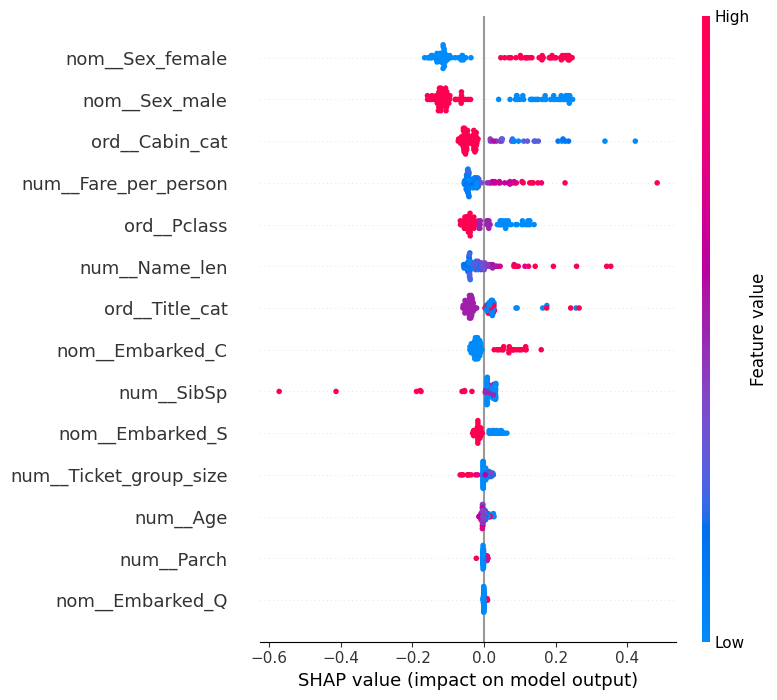

In [115]:
gnb_values = excecute_shap(
        model_data=gnb_b_model,
        features=f,
        target=t
        )

### Registry model

In [116]:
model_registry.register(
        model_name="GNB",
        best_parameters=gnb_b_model["best_parameters"],
        pipeline=gnb_b_model["best_pipeline"],
        metrics={
            "accuracy"  : gnb_b_model["best_score"],
            "base_score": base_score
            }
        )
model_registry.show()

,model_name,best_parameters,accuracy,base_score
1,SVC,"{'classifier__estimator__C': 1.0, 'classifier__estimator__gamma': 'scale'}",0.8384,0.8328
2,KNN,"{'classifier__n_neighbors': 5, 'classifier__p': 1, 'classifier__weights': 'uniform'}",0.8339,0.8283
0,LogisticRegression_SAGA,"{'classifier__C': 0.1, 'classifier__l1_ratio': 0.5}",0.7969,0.8002
3,LDA,"{'classifier__shrinkage': None, 'classifier__solver': 'svd'}",0.7912,0.7890
4,GNB,{'classifier__var_smoothing': 1e-09},0.7868,0.7823


### Semi-conclusion
* **Core Mechanism**: The "Naive" Independence Assumption
Gaussian Naive Bayes classifies data by calculating the probability of each class and multiplying the individual probabilities of each feature. The "naive" assumption is that every feature contributes independently to the outcome, completely ignoring any complex interactions or correlations between features. It evaluates each variable in strict isolation.

* **The Probabilistic Foundation**: The Gaussian Bell Curve
To handle continuous variables like Age or Fare, the algorithm assumes the data for each class follows a normal (Gaussian) distribution. It simply calculates the mean and variance for each feature within each class, effectively fitting a bell curve to the training data. A new data point is classified based on which class's bell curves it aligns with most naturally.

* **The Trade-off**: Speed and Simplicity vs. Reality
In the real world, features are rarely completely independent, which means the model's probability estimates can become artificially overconfident. However, this "naive" simplification is also its greatest strength: because it does not attempt to learn complex feature interactions, it is exceptionally fast, highly scalable, and remarkably resistant to overfitting, even when trained on very small datasets.
---

# Single Base models: Tree-Based Ensembles

## Decision Tree
### Overview

**Historical Context**
The foundational algorithms for decision trees were developed in the 1960s by Hunt, Landis, and Moore (Concept Learning Systems). The modern framework was formalized in the 1980s through two parallel paradigms: J. Ross Quinlan's ID3 (1986) and C4.5 algorithms, which utilized Information Gain (Entropy) for feature selection, and Leo Breiman et al.'s CART (1984) algorithm, which introduced the Gini Impurity metric and the recursive binary partitioning methodology standard in modern implementations.

**Mathematical Formulation**
A decision tree constructs a predictive model by recursively partitioning the feature space $\mathcal{X} \subset \mathbb{R}^d$ into $M$ disjoint, non-overlapping regions $R_1, R_2, \dots, R_M$. Each region is defined by a sequence of binary split rules of the form $X_j \leq t$, where $X_j$ is a specific feature and $t$ is a threshold.

For a given region $R_m$, let $p_{mk}$ represent the proportion of training samples belonging to class $k \in \{1, \dots, K\}$. The tree selects the optimal feature $j$ and threshold $t$ at each node by maximizing the reduction in node impurity $\Phi$. The two standard impurity measures are Gini Impurity and Entropy:
$$ \text{Gini}(R_m) = 1 - \sum_{k=1}^{K} p_{mk}^2 $$
$$ \text{Entropy}(R_m) = -\sum_{k=1}^{K} p_{mk} \log_2(p_{mk}) $$

The algorithm greedily searches for the split that minimizes the weighted sum of the impurities of the resulting child nodes ($R_{left}$ and $R_{right}$):
$$ \arg\min_{j, t} \left( \frac{N_{left}}{N_{parent}} \Phi(R_{left}) + \frac{N_{right}}{N_{parent}} \Phi(R_{right}) \right) $$
where $N$ denotes the number of samples in the respective nodes.

Once the tree is fully grown, the prediction $\hat{y}$ for a query point $\mathbf{x}$ falling into region $R_m$ is determined by the majority class (mode) of the training samples within that region:
$$ \hat{y}(\mathbf{x}) = \arg\max_{k} p_{mk} \quad \text{for } \mathbf{x} \in R_m $$

Because an unconstrained decision tree will recursively partition the space until every leaf node is perfectly pure, it is highly susceptible to overfitting (high variance). Therefore, structural constraints—such as maximum depth, minimum samples per split, and minimum samples per leaf—are mathematically critical to act as pre-pruning mechanisms, controlling the model's complexity and ensuring generalization.

### Feature Engineering & Selection Rationale

1. Continuous vs. Discretized (Binned) Features
While decision trees are mathematically capable of finding optimal continuous split thresholds, they operate blindly without domain context. By explicitly binning continuous variables into human-interpretable categories (e.g., transforming exact `Age` into a "child" or "young" group), we inject structural domain knowledge directly into the model. This provides a strong inductive bias, guiding the tree to evaluate survival-relevant life stages rather than overfitting to noisy, granular continuous values (like the arbitrary difference between age 24 and 25). Binning effectively reduces the tree's search space and forces it to respect meaningful structural thresholds.
* **Decision:** Include both the original continuous features and their engineered categorical counterparts (`Age_cat`, `Fare_per_person_cat`, etc.). The decision tree will naturally evaluate and select the representation (continuous or binned) that yields the highest information gain at each node.

2. Multicollinearity and Feature Importance Dilution
Tree-based models do not suffer from matrix singularity, but they suffer from *feature importance dilution*. When highly correlated features are present, the algorithm randomly selects one to split on at a given node. The predictive power of the underlying concept is fractured across the correlated variables, artificially suppressing their individual importance scores in post-hoc analysis.
* `Family_size` is an exact linear combination of `SibSp` and `Parch`. Including it guarantees that the "family" signal is split, diluting its measured importance. The derived continuous column is dropped (though its binned version, `Family_size_cat`, is retained).
* `Fare` and `Fare_per_person` are highly correlated. The raw `Fare` is dropped in favor of the normalized `Fare_per_person` (and its binned counterpart) to maintain a clean, undiluted feature space.

3. Categorical Encoding Strategy (Nominal vs. Ordinal)
Tree algorithms evaluate features by sorting them and searching for split thresholds. The encoding strategy must align with how the tree processes these splits:
* **Ordinal Features:** Categories with a strict hierarchy or natural progression (e.g., `Pclass`, `Age_cat`, `Fare_per_person_cat`). Mapping these to integers allows the tree to capture the relationship with a single, clean threshold split (e.g., `Age_cat <= 1` to isolate the "child" group).
* **Nominal Features:** Categories without inherent ordering (e.g., `Embarked`, `Sex`). If mapped to integers, the tree is forced to create multiple, inefficient, and disjoint splits to capture the true relationship. These must be One-Hot Encoded to provide independent, orthogonal binary split opportunities.

4. Final Feature Partition
The feature space is partitioned into three distinct groups for the preprocessing pipeline:

    * **Numeric Features:**
`Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len`.
        **Preprocessing:** Median imputation only. **Crucial Distinction:** Standard Scaling is mathematically unnecessary and computationally wasteful for tree-based models. Decision tree splits are strictly invariant to monotonic transformations; scaling does not alter the order of the data or the resulting split thresholds.

    * **Ordinal Categorical Features:**
`Pclass`, `Title_cat`, `Cabin_cat`, `Age_cat`, `Family_size_cat`, `Ticket_group_size_cat`, `Fare_per_person_cat`, `Name_len_cat`.
        **Preprocessing:** Ordinal Encoding to map inherent hierarchies and human-defined bins into integer sequences, enabling efficient single-threshold splits.

    * **Nominal Categorical Features:**
`Sex`, `Embarked`.
        **Preprocessing:** One-Hot Encoding to generate orthogonal binary indicators, allowing the tree to evaluate each category independently without assuming false geometric distances.

### Functions

In [120]:
from sklearn.tree import DecisionTreeClassifier

In [129]:
def define_dt_feature_subsets(
        numeric_features: List[str],
        nominal_categorical_features: List[str],
        ordinal_categorical_features: List[str]
        ) -> Dict[str, List[str]]:
    return {
        "numeric_features"            : numeric_features,
        "nominal_categorical_features": nominal_categorical_features,
        "ordinal_features"            : ordinal_categorical_features,
    }


def build_dt_preprocessor(features: Dict[str, List[str]]) -> ColumnTransformer:
    nominal_transformer = Pipeline(
            steps=[
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
                ]
            )
    ordinal_transformer = Pipeline(
            steps=[
                ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
                ]
            )
    preprocessor = ColumnTransformer(
            transformers=[
                ("num", "passthrough", features["numeric_features"]),
                ("nom", nominal_transformer, features["nominal_categorical_features"]),
                ("ord", ordinal_transformer, features["ordinal_features"]),
                ]
            )
    return preprocessor


def build_dt_pipeline(preprocessor: ColumnTransformer) -> Pipeline:
    classifier = DecisionTreeClassifier(
            criterion="gini",
            splitter="best",
            random_state=42
            )

    pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", classifier)
                ]
            )
    return pipeline

### Base prediction

In [130]:
features = define_dt_feature_subsets(
        numeric_features=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
        nominal_categorical_features=["Sex", "Embarked"],
        ordinal_categorical_features=["Pclass", "Title_cat", "Cabin_cat"]
        )

f, t = prepare_features_and_target(train_df, "Survived", features)
dt_preprocessor = build_dt_preprocessor(features)
dt_pipeline = build_dt_pipeline(dt_preprocessor)
base_score = train_and_evaluate_model(dt_pipeline, f, t)
print(f"Base score: {base_score:.4f}")

Base score: 0.7519


### Tune hyperparameters

In [133]:
def define_dt_search_space(
        classifier_criterion: List[str] | None = None,
        classifier_max_depth: List[int | None] | None = None,
        classifier_min_samples_split: List[int] | None = None,
        classifier_min_samples_leaf: List[int] | None = None
        ) -> Dict[str, List[Any]]:
    if classifier_criterion is None:
        classifier_criterion = ["gini", "entropy"]
    if classifier_max_depth is None:
        classifier_max_depth = [None, 5, 10, 15, 20]
    if classifier_min_samples_split is None:
        classifier_min_samples_split = [2, 5, 10]
    if classifier_min_samples_leaf is None:
        classifier_min_samples_leaf = [1, 2, 4]

    search_space: Dict[str, List[Any]] = {
        "classifier__criterion"        : classifier_criterion,
        "classifier__max_depth"        : classifier_max_depth,
        "classifier__min_samples_split": classifier_min_samples_split,
        "classifier__min_samples_leaf" : classifier_min_samples_leaf,
    }
    return search_space


def tune_dt_hyperparameters(
        pipeline: Pipeline,
        feature_matrix: pd.DataFrame,
        target_vector: pd.Series,
        search_space: Dict[str, List[Any]],
        cross_validator: BaseCrossValidator,
        scoring: str = "accuracy"
        ) -> Dict[str, Any]:
    grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=search_space,
            scoring=scoring,
            cv=cross_validator,
            n_jobs=-1,
            refit=True,
            error_score="raise"
            )

    grid_search.fit(feature_matrix, target_vector)

    return {
        "best_pipeline"  : grid_search.best_estimator_,
        "best_parameters": grid_search.best_params_,
        "best_score"     : float(grid_search.best_score_)
    }

In [134]:
dt_b_model = tune_dt_hyperparameters(
        dt_pipeline, f, t, define_dt_search_space(), StratifiedKFold()
        )

print(f"Best score: {dt_b_model['best_score']:.4f}")

Best score: 0.8171


### SHAP analysis

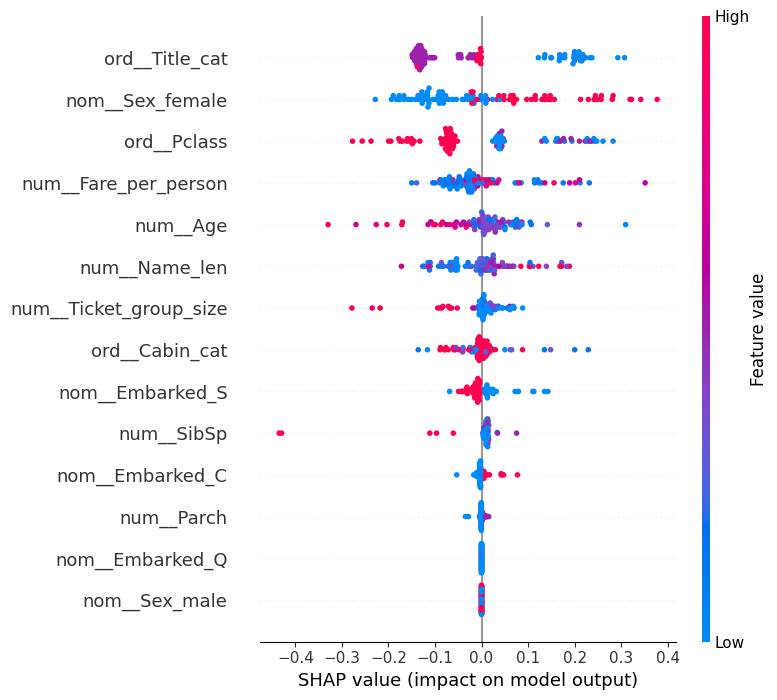

In [135]:
dt_values = excecute_shap(dt_b_model, f, t)

### Registry model

In [136]:
model_registry.register(
        model_name="Decision tree",
        best_parameters=dt_b_model["best_parameters"],
        pipeline=dt_b_model["best_pipeline"],
        metrics={
            "accuracy"  : dt_b_model["best_score"],
            "base_score": base_score
            }
        )
model_registry.show()

,model_name,best_parameters,accuracy,base_score
1,SVC,"{'classifier__estimator__C': 1.0, 'classifier__estimator__gamma': 'scale'}",0.8384,0.8328
2,KNN,"{'classifier__n_neighbors': 5, 'classifier__p': 1, 'classifier__weights': 'uniform'}",0.8339,0.8283
5,Decision tree,"{'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10}",0.8171,0.7519
0,LogisticRegression_SAGA,"{'classifier__C': 0.1, 'classifier__l1_ratio': 0.5}",0.7969,0.8002
3,LDA,"{'classifier__shrinkage': None, 'classifier__solver': 'svd'}",0.7912,0.7890
4,GNB,{'classifier__var_smoothing': 1e-09},0.7868,0.7823


### Semi-conclusion
* **Core Mechanism**: Recursive Binary Partitioning
The Decision Tree constructs a predictive model by recursively dividing the feature space into disjoint, rectangular regions. At each node, the algorithm evaluates features and thresholds to find the single best binary split that most effectively separates the classes. In practice, the model operates as a transparent, interpretable cascade of if-then logical rules, routing each data point down a specific path to a final leaf node.

* **The Structural Shift**: Greedy Impurity Optimization
Unlike models that optimize a global mathematical function via gradient descent or geometric margins, the tree builds its structure greedily, one node at a time. It relies on impurity metrics—such as Gini Impurity or Information Entropy—to quantify class mixing. The algorithm strictly seeks the split that yields the maximum immediate reduction in impurity, making locally optimal decisions at each step without calculating the global optimality of the entire tree structure.

* **The Risk**: Unconstrained Overfitting and High Variance
Because the algorithm will recursively partition the data until every leaf node is perfectly pure (containing only a single class), an unconstrained tree will inevitably memorize the training data, capturing all underlying noise and outliers. This results in a model with extremely high variance and poor generalization to unseen data. To mitigate this risk, strict structural constraints (pre-pruning)—such as maximum depth, minimum samples per split, or minimum samples per leaf—must be mathematically enforced to halt the tree's growth and ensure a robust, generalized decision boundary.
---

## Random Forest
### Overview

**Historical Context**
The Random Forest algorithm was formally introduced by Leo Breiman in 2001, building upon his earlier work on Bootstrap Aggregating (bagging) in 1996 and Tin Kam Ho's stochastic subspace method from 1995. It was designed to address the high variance and overfitting tendencies of individual decision trees by introducing controlled randomness into both the data sampling and the feature selection processes.

**Mathematical Formulation**
Random Forest is an ensemble learning method that constructs a multitude of decision trees during training and outputs the mode of their predictions. It introduces two distinct layers of randomness to decorrelate the individual estimators.

Let $\mathcal{D} = \{(\mathbf{x}_1, y_1), \dots, (\mathbf{x}_N, y_N)\}$ be the training dataset. The algorithm constructs an ensemble of $K$ decision trees $\{T_1, T_2, \dots, T_K\}$.

1. **Bootstrap Aggregating (Bagging):** Each tree $T_k$ is trained on a bootstrap sample $\mathcal{D}_k$ of size $N$, drawn uniformly with replacement from $\mathcal{D}$. This ensures each tree is trained on a slightly different distribution of the data, reducing the model's sensitivity to specific noise points.

2. **Feature Randomness (Random Subspace):** During the recursive partitioning of each tree, at every node split, the algorithm does not evaluate all $d$ features. Instead, it randomly selects a subset of $m$ features (typically $m \approx \sqrt{d}$ for classification) and chooses the optimal split only from this subset.

3. **Aggregation:** For a query point $\mathbf{x}$, the final predicted class label $\hat{y}$ is determined by a majority vote across all $K$ trees:
$$ \hat{y} = \arg\max_{c} \sum_{k=1}^{K} \mathbb{I}(T_k(\mathbf{x}) = c) $$
where $\mathbb{I}(\cdot)$ is the indicator function.

4. **Variance Reduction:** The core mathematical justification for the feature randomness is the decorrelation of the trees. The variance of the ensemble of $K$ trees is given by $\rho \sigma^2$, where $\sigma^2$ is the variance of a single tree and $\rho$ is the Pearson correlation between any two trees in the ensemble. By restricting the candidate features at each split, the algorithm forces the trees to utilize different structural pathways, thereby minimizing $\rho$. This drastically reduces the overall variance of the ensemble without increasing the bias, yielding a highly robust and generalizable model.

### Feature Engineering & Selection Rationale

1. Continuous vs. Discretized (Binned) Features
While Random Forests can naturally handle continuous variables by finding optimal split thresholds, they operate without domain context. By explicitly binning continuous variables into human-interpretable categories (e.g., transforming exact `Age` into "child", "young", or "elderly" groups), we inject structural domain knowledge directly into the model. This provides a strong inductive bias, guiding the ensemble to evaluate survival-relevant life stages rather than overfitting to noisy, granular continuous values. Binning effectively reduces the search space for individual trees and forces them to respect meaningful structural thresholds.
* **Decision:** Include both the original continuous features and their engineered categorical counterparts (`Age_cat`, `Fare_per_person_cat`, etc.). The Random Forest's internal feature selection will naturally evaluate and utilize the representation (continuous or binned) that yields the highest information gain.

2. Multicollinearity and Feature Importance Dilution
Tree-based ensembles do not suffer from matrix singularity, but they are susceptible to *feature importance dilution*. When highly correlated features are present, the algorithm randomly selects one to split on at a given node. The predictive power of the underlying concept is fractured across the correlated variables, artificially suppressing their individual importance scores in post-hoc analysis (such as SHAP).
* `Family_size` is an exact linear combination of `SibSp` and `Parch`. Including it guarantees that the "family" signal is split, diluting its measured importance. The derived continuous column is dropped (though its binned version, `Family_size_cat`, is retained).
* `Fare` and `Fare_per_person` are highly correlated. The raw `Fare` is dropped in favor of the normalized `Fare_per_person` (and its binned counterpart) to maintain a clean, undiluted feature space.

3. Categorical Encoding Strategy (Nominal vs. Ordinal)
Tree algorithms evaluate features by sorting them and searching for split thresholds. The encoding strategy must align with how the tree processes these splits:
* **Ordinal Features:** Categories with a strict hierarchy or natural progression (e.g., `Pclass`, `Age_cat`, `Fare_per_person_cat`). Mapping these to integers allows the tree to capture the relationship with a single, clean threshold split (e.g., `Age_cat <= 1` to isolate the "child" group).
* **Nominal Features:** Categories without inherent ordering (e.g., `Embarked`, `Sex`). If mapped to integers, the tree is forced to create multiple, inefficient, and disjoint splits to capture the true relationship. These must be One-Hot Encoded to provide independent, orthogonal binary split opportunities.

4. Final Feature Partition
The feature space is partitioned into three distinct groups for the preprocessing pipeline:

    * **Numeric Features:**
`Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len`.
        **Preprocessing:** Median imputation only. **Crucial Distinction:** Standard Scaling is mathematically unnecessary and computationally wasteful for tree-based models. Decision tree splits are strictly invariant to monotonic transformations; scaling does not alter the order of the data or the resulting split thresholds.

    * **Ordinal Categorical Features:**
`Pclass`, `Title_cat`, `Cabin_cat`, `Age_cat`, `Family_size_cat`, `Ticket_group_size_cat`, `Fare_per_person_cat`, `Name_len_cat`.
        **Preprocessing:** Ordinal Encoding to map inherent hierarchies and human-defined bins into integer sequences, enabling efficient single-threshold splits.

    * **Nominal Categorical Features:**
`Sex`, `Embarked`.
        **Preprocessing:** One-Hot Encoding to generate orthogonal binary indicators, allowing the tree to evaluate each category independently without assuming false geometric distances.


### Functions

In [137]:
from sklearn.ensemble import RandomForestClassifier

In [138]:
def define_rf_feature_subsets(
        numeric_features: List[str],
        nominal_categorical_features: List[str],
        ordinal_categorical_features: List[str]
        ) -> Dict[str, List[str]]:
    return {
        "numeric_features"            : numeric_features,
        "nominal_categorical_features": nominal_categorical_features,
        "ordinal_features"            : ordinal_categorical_features,
        }


def build_rf_preprocessor(features: Dict[str, List[str]]) -> ColumnTransformer:
    nominal_transformer = Pipeline(
            steps=[
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
                ]
            )

    ordinal_transformer = Pipeline(
            steps=[
                ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
                ]
            )

    preprocessor = ColumnTransformer(
            transformers=[
                ("num", "passthrough", features["numeric_features"]),
                ("nom", nominal_transformer, features["nominal_categorical_features"]),
                ("ord", ordinal_transformer, features["ordinal_features"]),
                ]
            )
    return preprocessor


def build_rf_pipeline(preprocessor: ColumnTransformer) -> Pipeline:
    classifier = RandomForestClassifier(
            n_estimators=100,
            criterion="gini",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=42,
            n_jobs=-1
            )

    pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", classifier)
                ]
            )
    return pipeline

### Base prediction

In [139]:
features = define_rf_feature_subsets(
        numeric_features=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
        nominal_categorical_features=["Sex", "Embarked"],
        ordinal_categorical_features=["Pclass", "Title_cat", "Cabin_cat", "Age_cat", "Family_size_cat",
                                      "Ticket_group_size_cat", "Fare_per_person_cat", "Name_len_cat"]
        )

f, t = prepare_features_and_target(train_df, "Survived", features)
rf_preprocessor = build_rf_preprocessor(features)
rf_pipeline = build_rf_pipeline(rf_preprocessor)
base_score = train_and_evaluate_model(rf_pipeline, f, t)
print(f"Base score: {base_score:.4f}")

Base score: 0.8282


### Tune hyperparameters

In [144]:
def define_rf_search_space(
        classifier_n_estimators: List[int] | None = None,
        classifier_max_depth: List[int | None] | None = None,
        classifier_min_samples_split: List[int] | None = None,
        classifier_min_samples_leaf: List[int] | None = None,
        classifier_max_features: List[str | None] | None = None
        ) -> Dict[str, List[Any]]:
    if classifier_n_estimators is None:
        classifier_n_estimators = [100, 200, 300]
    if classifier_max_depth is None:
        classifier_max_depth = [None, 5, 10, 15]
    if classifier_min_samples_split is None:
        classifier_min_samples_split = [2, 5, 10]
    if classifier_min_samples_leaf is None:
        classifier_min_samples_leaf = [1, 2, 4]
    if classifier_max_features is None:
        classifier_max_features = ["sqrt", "log2", None]

    search_space: Dict[str, List[Any]] = {
        "classifier__n_estimators"     : classifier_n_estimators,
        "classifier__max_depth"        : classifier_max_depth,
        "classifier__min_samples_split": classifier_min_samples_split,
        "classifier__min_samples_leaf" : classifier_min_samples_leaf,
        "classifier__max_features"     : classifier_max_features,
        }
    return search_space


def tune_rf_hyperparameters(
        pipeline: Pipeline,
        feature_matrix: pd.DataFrame,
        target_vector: pd.Series,
        search_space: Dict[str, List[Any]],
        cross_validator: BaseCrossValidator,
        scoring: str = "accuracy"
        ) -> Dict[str, Any]:
    grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=search_space,
            scoring=scoring,
            cv=cross_validator,
            n_jobs=4,
            refit=True,
            error_score="raise"
            )

    grid_search.fit(feature_matrix, target_vector)

    return {
        "best_pipeline"  : grid_search.best_estimator_,
        "best_parameters": grid_search.best_params_,
        "best_score"     : float(grid_search.best_score_)
        }

In [145]:
rf_b_model = tune_rf_hyperparameters(
        rf_pipeline, f, t, define_rf_search_space(), StratifiedKFold()
        )

print(f"Best score: {rf_b_model['best_score']:.4f}")

Best score: 0.8417


### SHap analysis

PermutationExplainer explainer: 101it [02:29,  1.59s/it]                         


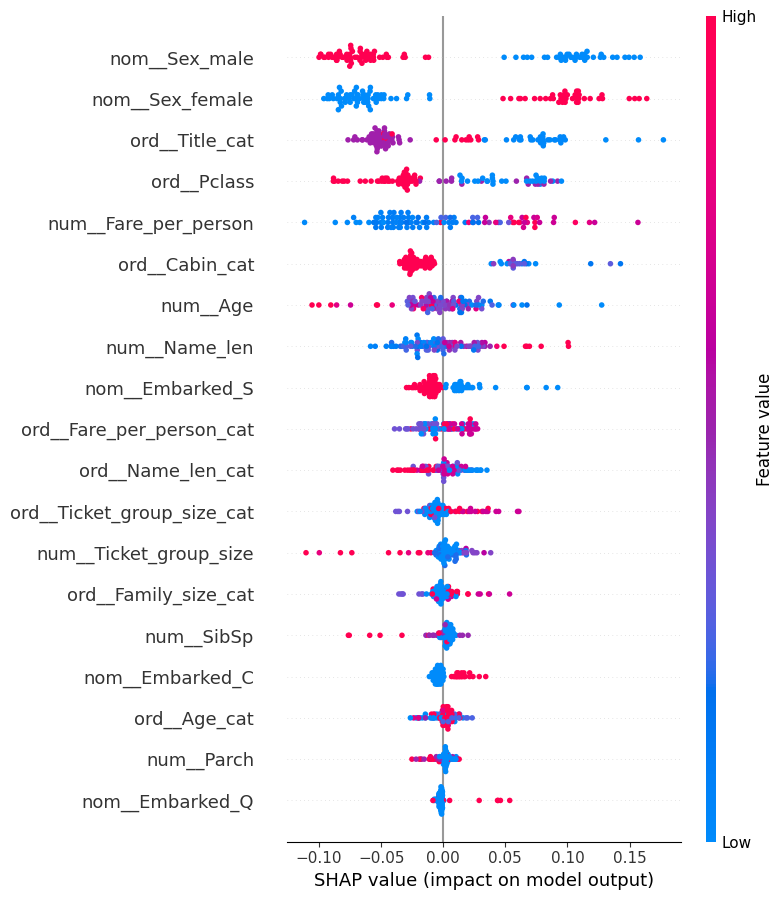

In [146]:
rf_values = excecute_shap(rf_b_model, f, t)

### Model registry

In [147]:
model_registry.register(
        model_name="Random Forest",
        best_parameters=rf_b_model["best_parameters"],
        pipeline=rf_b_model["best_pipeline"],
        metrics={
            "accuracy"  : rf_b_model["best_score"],
            "base_score": base_score
            }
        )
model_registry.show()

,model_name,best_parameters,accuracy,base_score
6,Random Forest,"{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}",0.8417,0.8282
1,SVC,"{'classifier__estimator__C': 1.0, 'classifier__estimator__gamma': 'scale'}",0.8384,0.8328
2,KNN,"{'classifier__n_neighbors': 5, 'classifier__p': 1, 'classifier__weights': 'uniform'}",0.8339,0.8283
5,Decision tree,"{'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10}",0.8171,0.7519
0,LogisticRegression_SAGA,"{'classifier__C': 0.1, 'classifier__l1_ratio': 0.5}",0.7969,0.8002
3,LDA,"{'classifier__shrinkage': None, 'classifier__solver': 'svd'}",0.7912,0.7890
4,GNB,{'classifier__var_smoothing': 1e-09},0.7868,0.7823


### Semi-conclusion
* **Core Mechanism**: Ensemble of Decorrelated Trees
Random Forest builds a multitude of decision trees and aggregates their predictions through majority voting. Its core innovation lies in introducing two layers of randomness—bootstrap sampling of the data and random feature selection at each split. This decorrelates the individual trees, ensuring that the ensemble does not simply amplify the mistakes of a single overfit tree.

* **The Variance Reduction**: The Power of Averaging
By averaging the predictions of many high-variance, low-bias models (deep decision trees), Random Forest dramatically reduces the overall variance of the ensemble. The random feature selection forces the trees to explore different structural pathways, preventing a single dominant feature from dictating the structure of every tree in the forest.

* **The Trade-off**: Interpretability vs. Robustness
While a single decision tree is highly interpretable, the Random Forest sacrifices this transparency for predictive power and robustness. It is resistant to overfitting and handles high-dimensional data well, but it operates as a "black box" where the exact decision logic is distributed across hundreds of trees, requiring tools like SHAP to interpret global and local feature importance.
---

In [149]:
model_registry.to_dataframe().to_csv("data/results/model_register.csv")